# Lab 6: 
#### Manasa ST
#### MCA-A
#### 2547133

## Aim
To implement Logistic Regression and K Nearest Neighbors (KNN) classifiers on the Breast Cancer Wisconsin (Diagnostic) dataset and compare their performance using standard classification evaluation metrics.

## 1. Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_style("whitegrid")

## 2. Load the Dataset

Dataset downloaded from the UCI repository and stored locally as `data/wdbc.data` (no header row, column names attached manually as per `data/wdbc.names`).

In [23]:
DATA_PATH = "wdbc.data"

columns = ["id", "diagnosis"]
stats = ["mean", "se", "worst"]
features = ["radius", "texture", "perimeter", "area", "smoothness",
            "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension"]
for stat in stats:
    for feat in features:
        columns.append(f"{feat}_{stat}")

df = pd.read_csv(DATA_PATH, header=None, names=columns)

print(f"Shape: {df.shape}")
df.head()

Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Exploratory Data Analysis

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [25]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### 3.1 Check for Missing Values

In [26]:
print(df.isnull().sum().sum(), "missing values in the dataset")
print(df.duplicated().sum(), "duplicate rows in the dataset")

0 missing values in the dataset
0 duplicate rows in the dataset


### 3.2 Class Distribution

diagnosis
B    357
M    212
Name: count, dtype: int64


/tmp/ipykernel_36049/3242398149.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="diagnosis", data=df, palette={"B": "#4C72B0", "M": "#C44E52"})


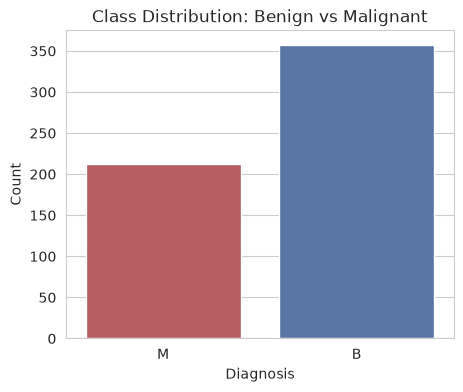

In [27]:
print(df["diagnosis"].value_counts())

plt.figure(figsize=(5, 4))
sns.countplot(x="diagnosis", data=df, palette={"B": "#4C72B0", "M": "#C44E52"})
plt.title("Class Distribution: Benign vs Malignant")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

### 3.3 Correlation Heatmap (mean features)

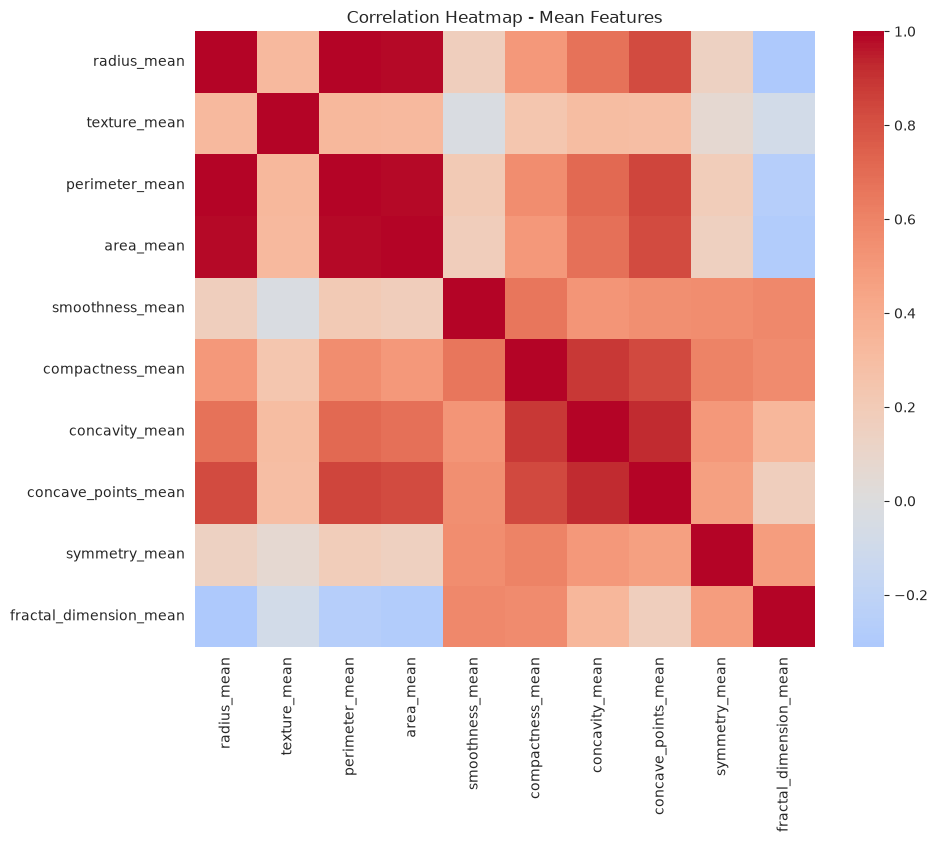

In [28]:
mean_cols = [c for c in df.columns if c.endswith("_mean")]

plt.figure(figsize=(10, 8))
sns.heatmap(df[mean_cols].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap - Mean Features")
plt.show()

## 4. Data Preprocessing

- Drop `id` column (not a predictive feature).
- Encode `diagnosis`: M -> 1, B -> 0.
- Separate features (X) and target (y).

In [29]:
df_proc = df.drop(columns=["id"]).copy()

le = LabelEncoder()
df_proc["diagnosis"] = le.fit_transform(df_proc["diagnosis"])  # B=0, M=1
print("Classes:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df_proc.drop(columns=["diagnosis"])
y = df_proc["diagnosis"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Classes: {'B': np.int64(0), 'M': np.int64(1)}
X shape: (569, 30)
y shape: (569,)


## 5. Train-Test Split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

Train set: (455, 30), Test set: (114, 30)


## 6. Feature Scaling

KNN is distance-based, so features must be scaled. Logistic Regression also converges better on scaled data. Scaler is fit only on train data to avoid leakage.

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done. Mean ~0, Std ~1 on train set:")
print(f"Train mean: {X_train_scaled.mean():.4f}, Train std: {X_train_scaled.std():.4f}")

Scaling done. Mean ~0, Std ~1 on train set:
Train mean: 0.0000, Train std: 1.0000


## 7. Train Logistic Regression Classifier

In [32]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
print("Logistic Regression trained.")

Logistic Regression trained.


## 8. Train K Nearest Neighbors (KNN) Classifier

### 8.1 Choosing k
Testing k = 1 to 20 on the test set to pick the best performing k.

Best k: 5, Accuracy: 0.9561


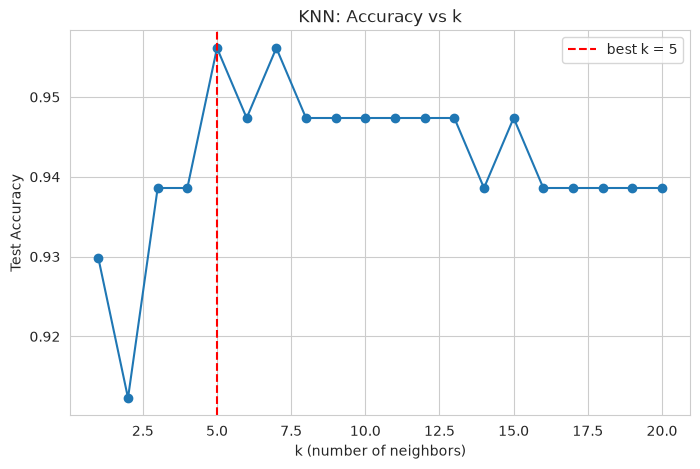

In [33]:
k_range = range(1, 21)
k_accuracies = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn_temp.predict(X_test_scaled))
    k_accuracies.append(acc)

best_k = list(k_range)[np.argmax(k_accuracies)]
print(f"Best k: {best_k}, Accuracy: {max(k_accuracies):.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), k_accuracies, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"best k = {best_k}")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Test Accuracy")
plt.title("KNN: Accuracy vs k")
plt.legend()
plt.show()

### 8.2 Train Final KNN Model

In [34]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
print(f"KNN trained with k = {best_k}.")

KNN trained with k = 5.


## 9. Model Evaluation

Metrics: Accuracy, Precision, Recall, F1 Score, Confusion Matrix. Positive class = Malignant (1).

In [35]:
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
    }

log_metrics = get_metrics(y_test, y_pred_log)
knn_metrics = get_metrics(y_test, y_pred_knn)

print("Logistic Regression:", log_metrics)
print("KNN:", knn_metrics)

Logistic Regression: {'Accuracy': 0.9649122807017544, 'Precision': 0.975, 'Recall': 0.9285714285714286, 'F1 Score': 0.9512195121951219}
KNN: {'Accuracy': 0.956140350877193, 'Precision': 0.9743589743589743, 'Recall': 0.9047619047619048, 'F1 Score': 0.9382716049382716}


### 9.1 Confusion Matrices

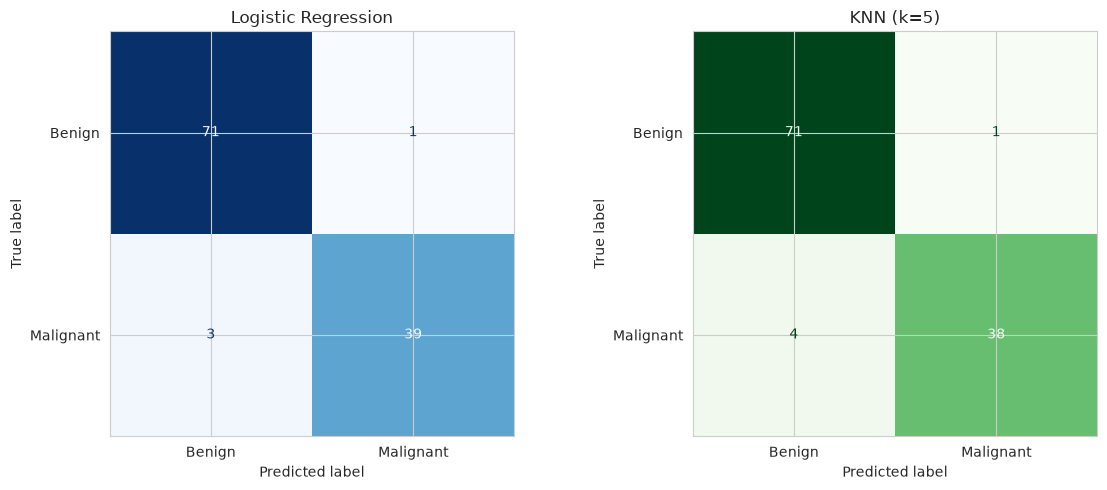

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_log, display_labels=["Benign", "Malignant"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Logistic Regression")

cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=["Benign", "Malignant"]).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"KNN (k={best_k})")

plt.tight_layout()
plt.show()

### 9.2 Classification Reports

In [37]:
print("Logistic Regression:\n")
print(classification_report(y_test, y_pred_log, target_names=["Benign", "Malignant"]))

print("KNN:\n")
print(classification_report(y_test, y_pred_knn, target_names=["Benign", "Malignant"]))

Logistic Regression:

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

KNN:

              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 10. Comparison Table

In [38]:
comparison_df = pd.DataFrame({
    "Logistic Regression": log_metrics,
    f"KNN (k={best_k})": knn_metrics,
}).T.round(4)

comparison_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.9649,0.9750,0.9286,0.9512
KNN (k=5),0.9561,0.9744,0.9048,0.9383


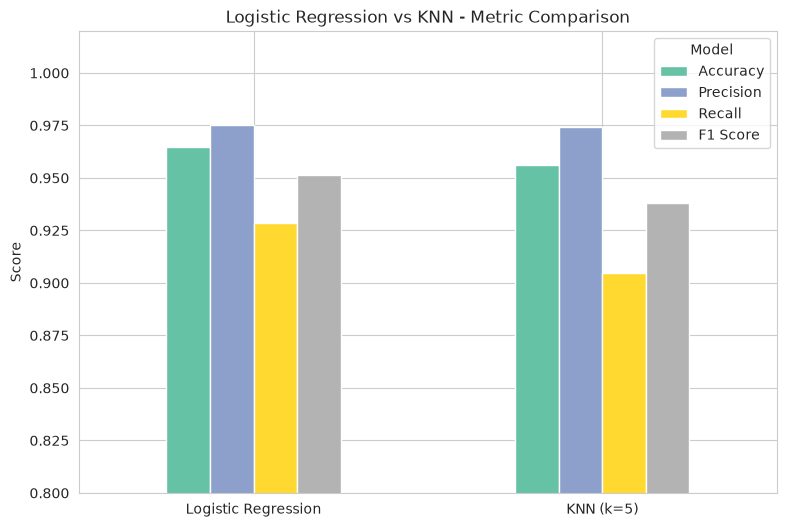

In [39]:
comparison_df.plot(kind="bar", figsize=(9, 6), rot=0, colormap="Set2")
plt.title("Logistic Regression vs KNN - Metric Comparison")
plt.ylabel("Score")
plt.ylim(0.8, 1.02)
plt.legend(title="Model")
plt.show()

## 11. Interpretation of Results

- Logistic Regression accuracy: **96.49%**
- KNN (k=5) accuracy: **95.61%**
- Logistic Regression has higher Precision, Recall and F1 Score too.
- Both models mostly confuse a few Malignant cases as Benign (false negatives) - the more critical error type for cancer diagnosis.
- Logistic Regression makes fewer such errors than KNN here.
- Best k for KNN was found to be **5** using the accuracy-vs-k sweep.
- Dataset is linearly well separated, which favors Logistic Regression.
- **Conclusion:** Logistic Regression is the better classifier for this dataset.